In [1]:
import numpy as np

EPS = 1e-12


# --------------------------------------------------
# Synthetic data generator
# --------------------------------------------------
def generate_synthetic(n=10000, corr_strength=0.0, noise=0.2):
    """
    Generates:
      - embeddings (2D for visualization)
      - attribute (binary predicate)
    corr_strength in [0,1] controls how much embedding correlates with attribute.
    """

    # embeddings: two clusters + noise
    cluster = np.random.rand(n) < 0.5
    emb = np.random.randn(n, 2) * noise
    emb[cluster] += np.array([2, 2])

    # attribute correlated with cluster but not perfectly
    attr = (cluster & (np.random.rand(n) < corr_strength)) | \
           (~cluster & (np.random.rand(n) < (1 - corr_strength)))

    return emb, attr.astype(int)


# --------------------------------------------------
# Neighborhood baseline (no global stats)
# --------------------------------------------------
def neighborhood_baseline(attr, neighbors):
    """
    Baseline selectivity = average predicate rate in neighborhood.
    """
    return np.mean(attr[neighbors])


# --------------------------------------------------
# JS divergence (binary)
# --------------------------------------------------
def js_divergence(p_local, p_base):
    p_local = np.clip(p_local, EPS, 1 - EPS)
    p_base = np.clip(p_base, EPS, 1 - EPS)

    m = 0.5 * (p_local + p_base)

    kl_local = p_local * np.log(p_local / m) + (1 - p_local) * np.log((1 - p_local) / (1 - m))
    kl_base  = p_base  * np.log(p_base  / m) + (1 - p_base)  * np.log((1 - p_base)  / (1 - m))

    return 0.5 * (kl_local + kl_base)


def build_cdf(attr, bins=100):
    hist, edges = np.histogram(attr, bins=bins, density=True)
    cdf = np.cumsum(hist)
    cdf = cdf / cdf[-1]
    return edges, cdf


def cdf_prob(edges, cdf, t):
    idx = np.searchsorted(edges, t, side='right') - 1
    idx = np.clip(idx, 0, len(cdf)-1)
    return cdf[idx]

# --------------------------------------------------
# Correlation strength (direction × magnitude)
# --------------------------------------------------
def correlation_strength(p_local, p_base, k):
    """Compute signed JS strength and z-score for binary predicate."""
    direction = np.sign(p_local - p_base)
    js = js_divergence(p_local, p_base)
    z = (p_local - p_base) / np.sqrt(p_base * (1 - p_base) / max(1, k) + EPS)
    return direction * js, z, js, direction


# --------------------------------------------------
# Experiment runner
# --------------------------------------------------
def experiment(corr_strength=0.0, threshold=1):
    emb, attr = generate_synthetic(corr_strength=corr_strength)

    n = len(emb)
    results = []

    # sample queries
    idx = np.random.choice(n, size=500, replace=False)
    queries = emb[idx]

    # precompute global baseline (fraction of positives)
    global_p = np.mean(attr)

    for q in queries:
        # neighborhood (no clustering, simple kNN)
        dists = np.linalg.norm(emb - q, axis=1)
        neighbors = np.argsort(dists)[1:51]  # exclude self

        local_attr = attr[neighbors]
        p_local = np.mean(local_attr)

        # compute strength using local and global rates
        strength, z, js, direction = correlation_strength(p_local, global_p, len(neighbors))

        results.append((strength, z, js, direction))

    return np.array(results)


# --------------------------------------------------
# Run experiments
# --------------------------------------------------
res_positive = experiment(corr_strength=0.9)
res_random   = experiment(corr_strength=0.0)
res_negative = experiment(corr_strength=0.1)  # inverted-ish relation

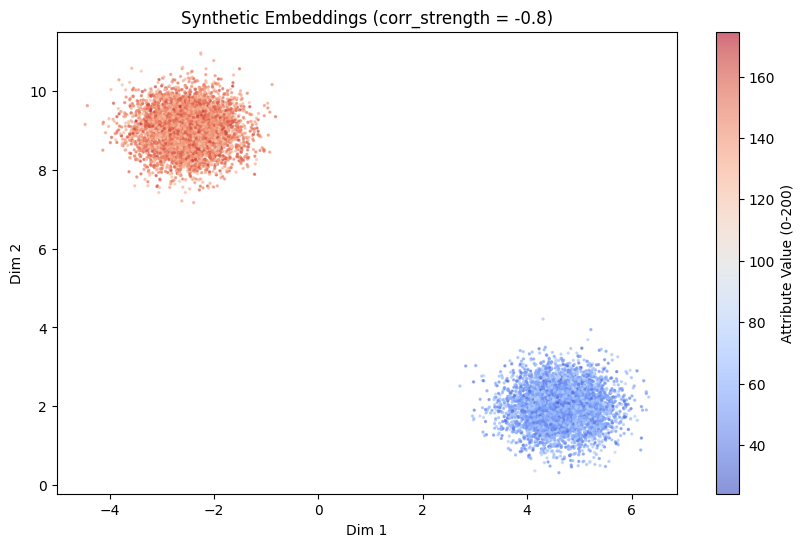

In [5]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

def generate_base_vectors(n=10000, centers=2, dims=2, cluster_std=0.5):
    """
    Creates n vectors clustered around 'centers' points.
    """
    # X = the 2D coordinates (embeddings)
    # y = the true cluster ID (we use this for the signal logic later)
    X, _ = make_blobs(n_samples=n, 
                      centers=centers, 
                      n_features=dims, 
                      cluster_std=cluster_std, 
                      random_state=42)
    return X

# Generate 10k vectors in 2D space
emb = generate_base_vectors(n=10000)

def get_correlated_attribute(emb, corr_strength=0.0):
    n = len(emb)
    # 1. Run K-Means to find the 2 clusters
    kmeans = MiniBatchKMeans(n_clusters=2, random_state=42, n_init=3)
    labels = kmeans.fit_predict(emb)

    # 2. Logic for Correlation (-1 to 1)
    # Base signal: Cluster 0 -> 0, Cluster 1 -> 1
    # If negative correlation: Cluster 0 -> 1, Cluster 1 -> 0
    if corr_strength >= 0:
        signal = labels.astype(float)
    else:
        signal = 1.0 - labels.astype(float)

    # 3. Map to 0-200 range with noise
    abs_corr = abs(corr_strength)
    
    # Target values (e.g., 50 vs 150)
    target_signal = 50 + (signal * 100)
    
    # Uniform noise across the whole spectrum
    random_noise = np.random.uniform(0, 200, n)
    
    # Final blend
    attr = (abs_corr * target_signal) + ((1 - abs_corr) * random_noise)
    
    # Add a tiny bit of Gaussian jitter (std dev of 5)
    attr += np.random.randn(n) * 5
    
    return np.clip(attr, 0, 200)

attr = get_correlated_attribute(emb, corr_strength=-0.8)

plt.figure(figsize=(10, 6))
plt.scatter(emb[:, 0], emb[:, 1], c=attr, cmap='coolwarm', s=2, alpha=0.6)
plt.colorbar(label="Attribute Value (0-200)")
plt.title(f"Synthetic Embeddings (corr_strength = -0.8)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [15]:
def calculate_pass_rate(attr_local, threshold=150):
    """
    Calculates p_q: The fraction of retrieved points that 
    satisfy the predicate (attribute > threshold).
    """
    if len(attr_local) == 0:
        return 0.0
    
    # Binary mask: True if attribute passes the threshold
    passed_predicate = attr_local < threshold
    
    # p_q = count of passed / total retrieved
    p_q = np.sum(passed_predicate) / len(attr_local)
    
    return p_q

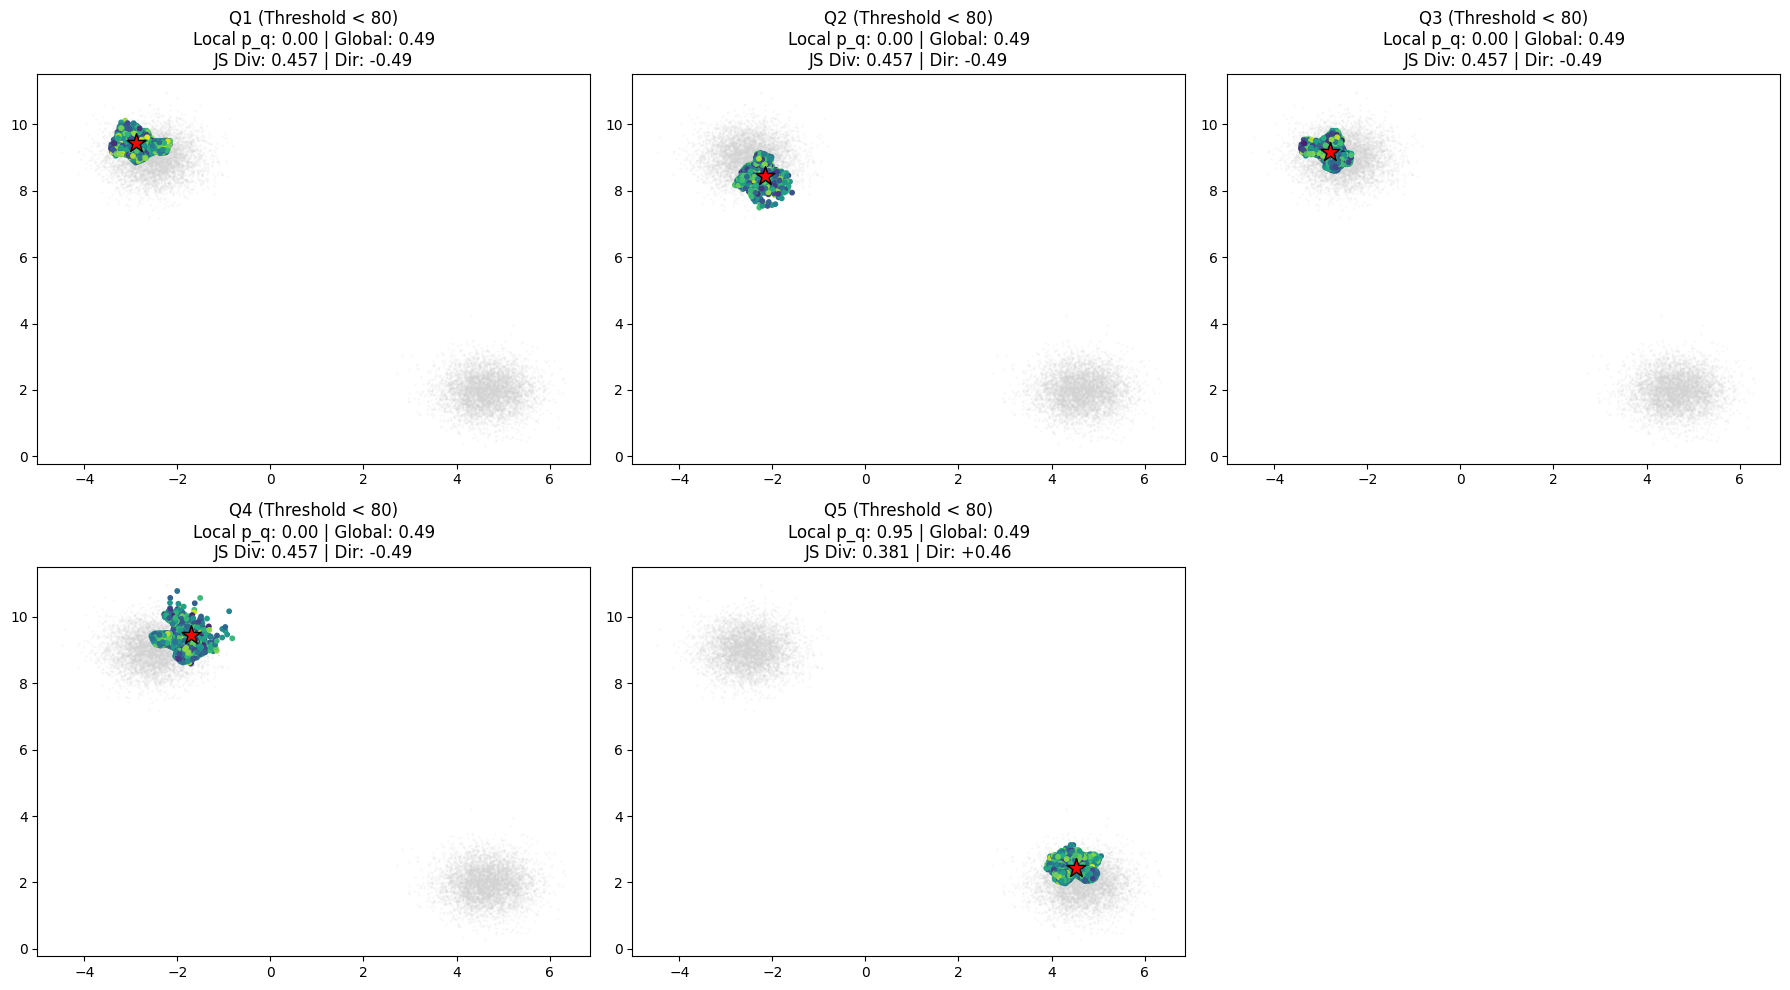

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.datasets import make_blobs
from scipy.spatial.distance import jensenshannon

def get_p_global(edges, cdf, threshold):
    idx = np.searchsorted(edges, threshold)
    if idx >= len(cdf): return 1.0
    return cdf[idx]

edges, cdf = build_cdf(attr)
# Pick a threshold that actually splits the data (e.g., 80)
threshold = 80 
p_global = get_p_global(edges, cdf, threshold)

# 3. Clustering
n_clusters = 60 # More clusters = more local variance
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(emb)
cluster_to_indices = {c: np.where(kmeans.labels_ == c)[0] for c in range(n_clusters)}

def _nearest_clusters(q, centroids, top_L=3):
    distances = np.linalg.norm(centroids - q, axis=1)
    return np.argsort(distances)[:top_L]

# 4. Process 5 Queries
queries = emb[np.random.choice(len(emb), size=5, replace=False)]
plt.figure(figsize=(18, 10))

for i, q in enumerate(queries):
    # Get local neighborhood
    neighbor_ids = _nearest_clusters(q, kmeans.cluster_centers_, top_L=6)
    local_idx = np.concatenate([cluster_to_indices[c] for c in neighbor_ids])
    
    X_local, attr_local = emb[local_idx], attr[local_idx]
    
    # Calculate p_q using < threshold
    p_q = np.mean(attr_local < threshold)
    direction = p_q - p_global
    
    # JS Divergence
    eps = 1e-10
    js_div = jensenshannon(np.clip([p_q, 1-p_q], eps, 1-eps), 
                           np.clip([p_global, 1-p_global], eps, 1-eps))
    
    # Plot
    plt.subplot(2, 3, i+1)
    plt.scatter(emb[:, 0], emb[:, 1], c='lightgrey', s=1, alpha=0.1)
    sc = plt.scatter(X_local[:, 0], X_local[:, 1], c=attr_local, cmap='viridis', s=10)
    plt.scatter(q[0], q[1], color='red', marker='*', s=200, edgecolors='black')
    
    plt.title(f"Q{i+1} (Threshold < {threshold})\nLocal p_q: {p_q:.2f} | Global: {p_global:.2f}\nJS Div: {js_div:.3f} | Dir: {direction:+.2f}")

plt.tight_layout()
plt.show()

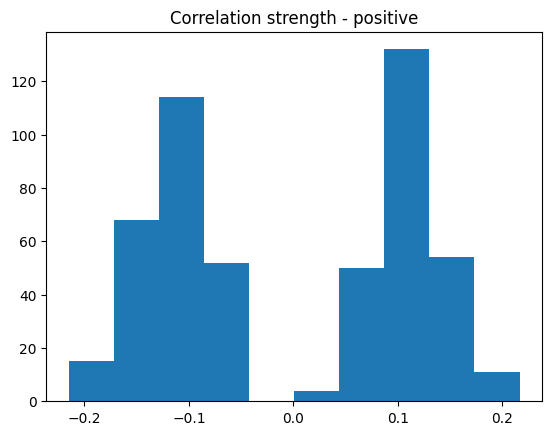

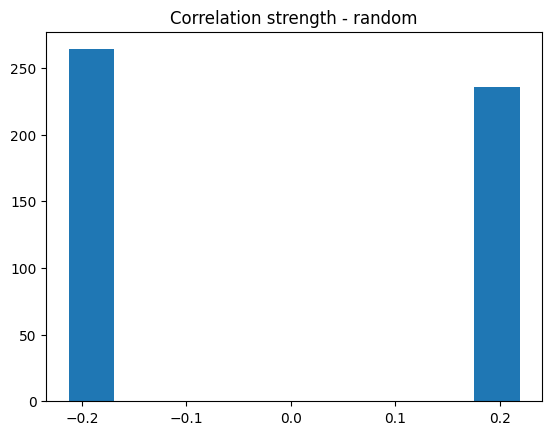

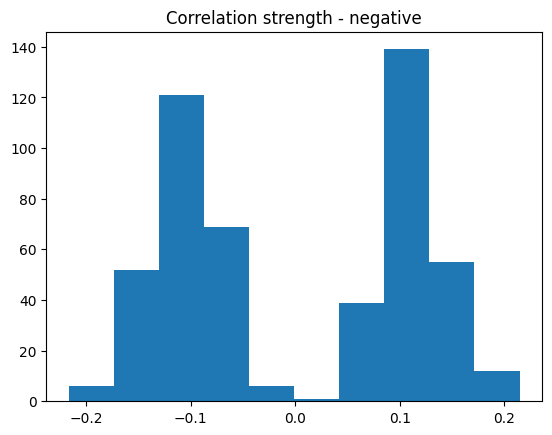

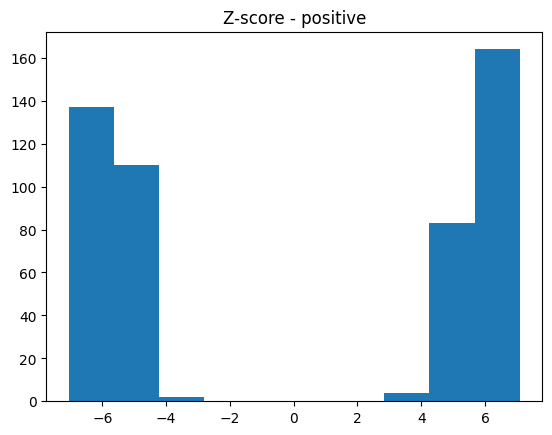

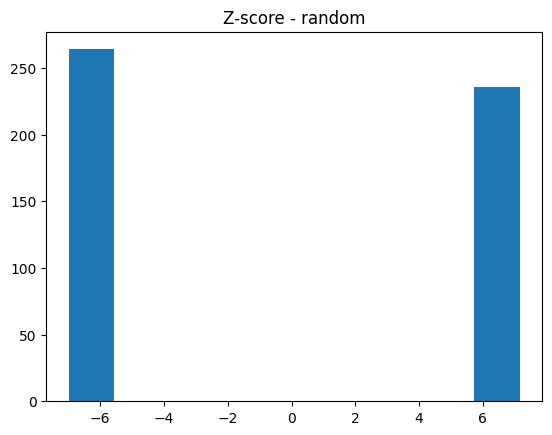

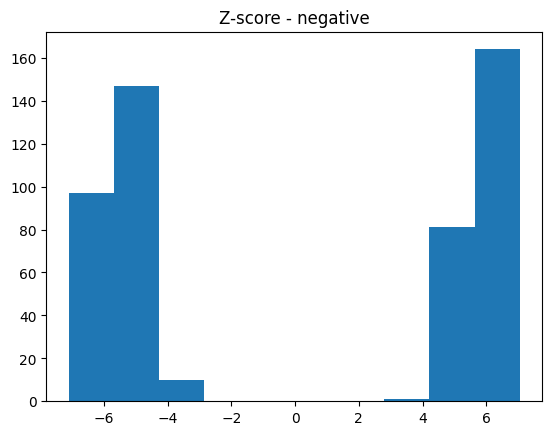

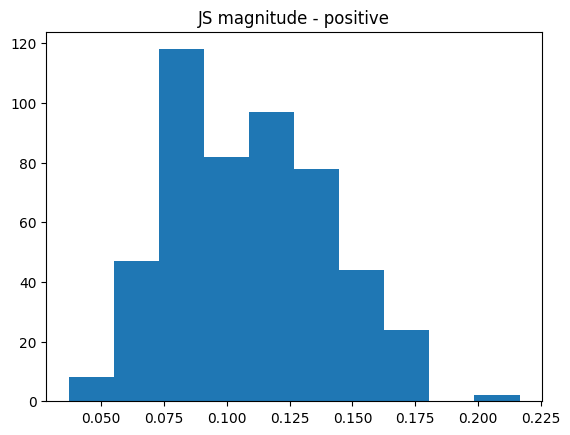

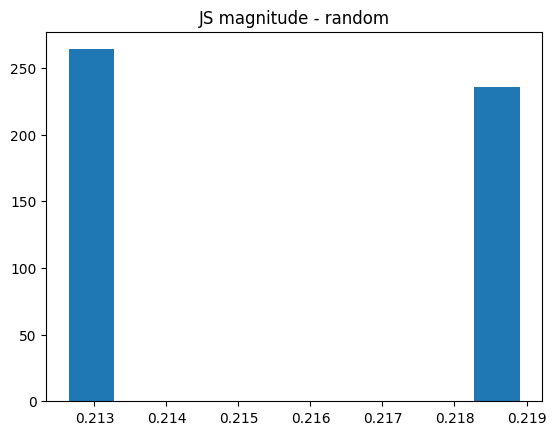

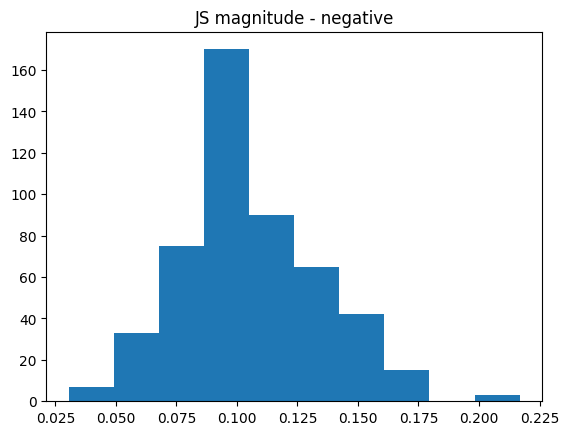

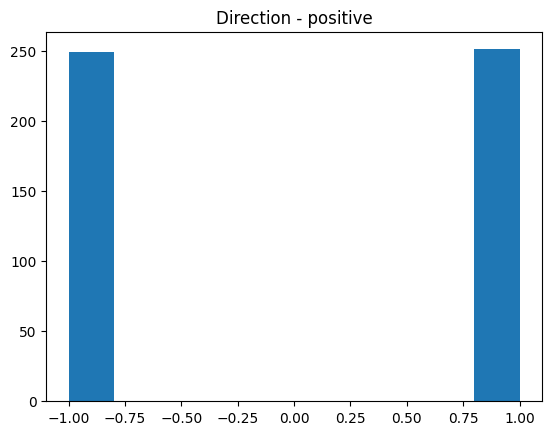

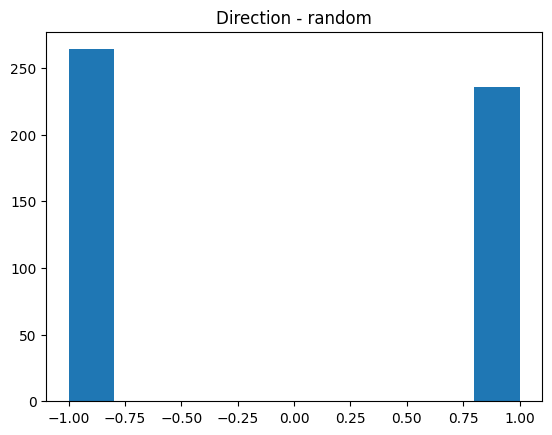

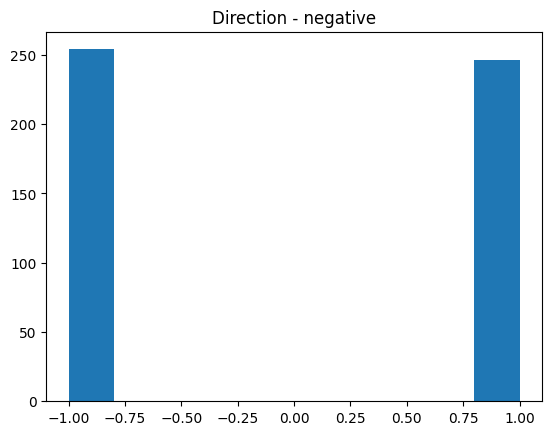

In [ ]:
# --------------------------------------------------
# Plotting (separate figures)
# --------------------------------------------------

def plot_hist(data, title):
    import matplotlib.pyplot as plt
    plt.figure()
    plt.hist(data)
    plt.title(title)
    plt.show()


# Correlation strength
plot_hist(res_positive[:, 0], "Correlation strength - positive")
plot_hist(res_random[:, 0], "Correlation strength - random")
plot_hist(res_negative[:, 0], "Correlation strength - negative")

# Z-score (confidence)
plot_hist(res_positive[:, 1], "Z-score - positive")
plot_hist(res_random[:, 1], "Z-score - random")
plot_hist(res_negative[:, 1], "Z-score - negative")

# JS magnitude
plot_hist(res_positive[:, 2], "JS magnitude - positive")
plot_hist(res_random[:, 2], "JS magnitude - random")
plot_hist(res_negative[:, 2], "JS magnitude - negative")

# Direction
plot_hist(res_positive[:, 3], "Direction - positive")
plot_hist(res_random[:, 3], "Direction - random")
plot_hist(res_negative[:, 3], "Direction - negative")